## Importing libraries and files

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data_source/dataset_olympics.csv')

## Data Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      70000 non-null  int64  
 1   Name    70000 non-null  object 
 2   Sex     70000 non-null  object 
 3   Age     67268 non-null  float64
 4   Height  53746 non-null  float64
 5   Weight  52899 non-null  float64
 6   Team    70000 non-null  object 
 7   NOC     70000 non-null  object 
 8   Games   70000 non-null  object 
 9   Year    70000 non-null  int64  
 10  Season  70000 non-null  object 
 11  City    70000 non-null  object 
 12  Sport   70000 non-null  object 
 13  Event   70000 non-null  object 
 14  Medal   9690 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 8.0+ MB


In [4]:
df.columns = df.columns.str.lower()

In [5]:
df.columns

Index(['id', 'name', 'sex', 'age', 'height', 'weight', 'team', 'noc', 'games',
       'year', 'season', 'city', 'sport', 'event', 'medal'],
      dtype='object')

In [38]:
df['season'].value_counts()

Summer    58084
Winter    11533
Name: season, dtype: int64

In [6]:
df.isna().sum()

id            0
name          0
sex           0
age        2732
height    16254
weight    17101
team          0
noc           0
games         0
year          0
season        0
city          0
sport         0
event         0
medal     60310
dtype: int64

In [7]:
df.duplicated().sum()

383

In [8]:
df.drop_duplicates(inplace= True)

In [9]:
df.describe()

,id,age,height,weight,year
count,69617.000000,66946.000000,53741.000000,52899.000000,69617.000000
mean,18073.006378,25.544260,175.504736,70.900216,1978.021862
std,10240.599374,6.253257,10.384481,14.217489,29.982224
min,1.000000,11.000000,127.000000,25.000000,1896.000000
25%,9303.000000,21.000000,168.000000,61.000000,1960.000000
50%,18029.000000,24.000000,175.000000,70.000000,1984.000000
75%,26965.000000,28.000000,183.000000,79.000000,2002.000000
max,35658.000000,88.000000,223.000000,214.000000,2016.000000


## Exploratory Data Analysis

In [10]:
df['medal'].value_counts(dropna=False)

NaN       59931
Gold       3290
Bronze     3208
Silver     3188
Name: medal, dtype: int64

In [11]:
df['has_medal'] = df['medal'].notna().astype(int)

In [12]:
df['has_medal'].value_counts(dropna=False)

0    59931
1     9686
Name: has_medal, dtype: int64

In [13]:
medal_map = { 0: "No Medal", 1:"Won Medal"}

df['medal_history'] = df['has_medal'].map(medal_map)

In [14]:
df['medal_history'].value_counts()

No Medal     59931
Won Medal     9686
Name: medal_history, dtype: int64

<Axes: >

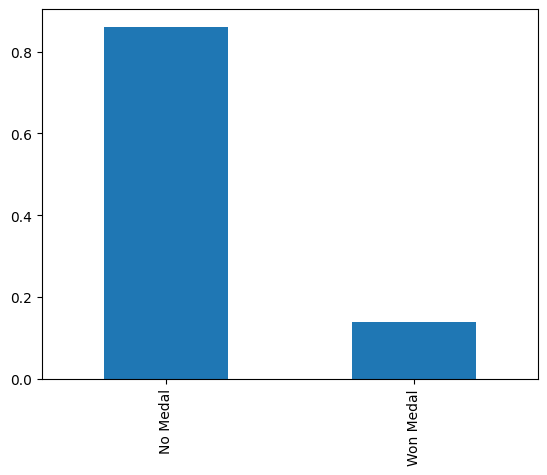

In [15]:
df['medal_history'].value_counts(normalize=True).plot(kind='bar')

More than 80% of athletes  never won a medal

In [24]:
df.groupby('sex')['age'].mean()

sex
F    23.721287
M    26.214509
Name: age, dtype: float64

In [25]:
df.groupby('sex')['height'].mean()

sex
F    167.92566
M    178.80924
Name: height, dtype: float64

In [33]:
df.groupby('medal_history')['height'].mean()

medal_history
No Medal     175.136150
Won Medal    177.822732
Name: height, dtype: float64

In [35]:
df['year'].nunique()

35

In [37]:
df.groupby('year')['id'].count()

year
1896      65
1900     623
1904     308
1906     431
1908     859
1912    1025
1920    1218
1924    1535
1928    1369
1932     763
1936    1768
1948    2066
1952    2444
1956    1617
1960    2489
1964    2346
1968    2745
1972    3058
1976    2756
1980    2389
1984    3135
1988    3873
1992    4176
1994     761
1996    3487
1998     855
2000    3525
2002     928
2004    3429
2006    1014
2008    3483
2010     902
2012    3377
2014    1123
2016    3675
Name: id, dtype: int64

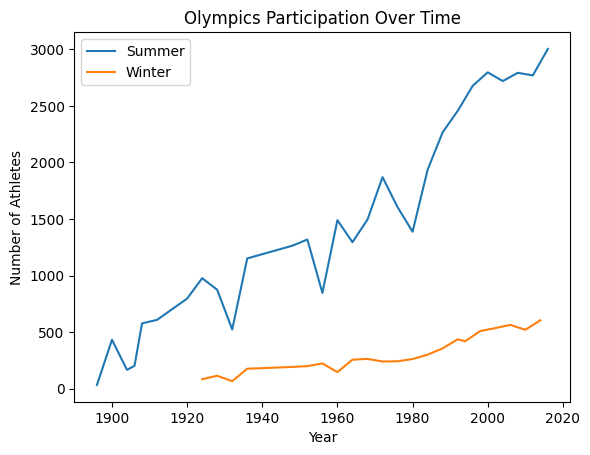

In [41]:
import matplotlib.pyplot as plt

summer_counts = df[df["season"] == "Summer"].groupby("year")["id"].nunique()
winter_counts = df[df["season"] == "Winter"].groupby("year")["id"].nunique()

plt.plot(summer_counts.index, summer_counts.values, label="Summer")
plt.plot(winter_counts.index, winter_counts.values, label="Winter")

plt.title("Olympics Participation Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Athletes")
plt.legend()

plt.show()

In [55]:
df[df['has_medal'] == 1].groupby(['sport','sex'])['age'].mean()


sport          sex
Alpine Skiing  F      23.309524
               M      25.564103
Alpinism       F      43.000000
               M      40.200000
Archery        F      28.285714
                        ...    
Water Polo     M      26.243478
Weightlifting  F      23.333333
               M      25.866667
Wrestling      F      26.750000
               M      26.120155
Name: age, Length: 111, dtype: float64

In [57]:
df[df['has_medal'] == 1] \
  .groupby(['sport','sex'])['age'] \
  .agg(['mean','count']) \
  .sort_values('mean').tail()

,,mean,count
sport,sex,,
Archery,M,37.604167,48
Alpinism,M,40.200000,5
Art Competitions,F,41.000000,1
Alpinism,F,43.000000,1
Art Competitions,M,43.000000,29


In [62]:
df[df['has_medal'] == 1].groupby(['sex'])['weight'].mean()

sex
F    62.968841
M    79.430628
Name: weight, dtype: float64

In [64]:
df['bmi'] = df['weight'] / ((df['height']/100) ** 2)


In [66]:
df.groupby('sport')['sex'].value_counts()


sport          sex
Alpine Skiing  M      1511
               F       815
Alpinism       M         6
               F         1
Archery        M       334
                      ... 
Water Polo     F       119
Weightlifting  M       924
               F        95
Wrestling      M      1766
               F        71
Name: sex, Length: 114, dtype: int64

/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2018/280953764.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_sports, x='sport', y='age', ax=axes[0], palette='Set2')
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2018/280953764.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_sports, x='sport', y='height', ax=axes[1], palette='Set3')
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2018/280953764.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_sports, x='sport

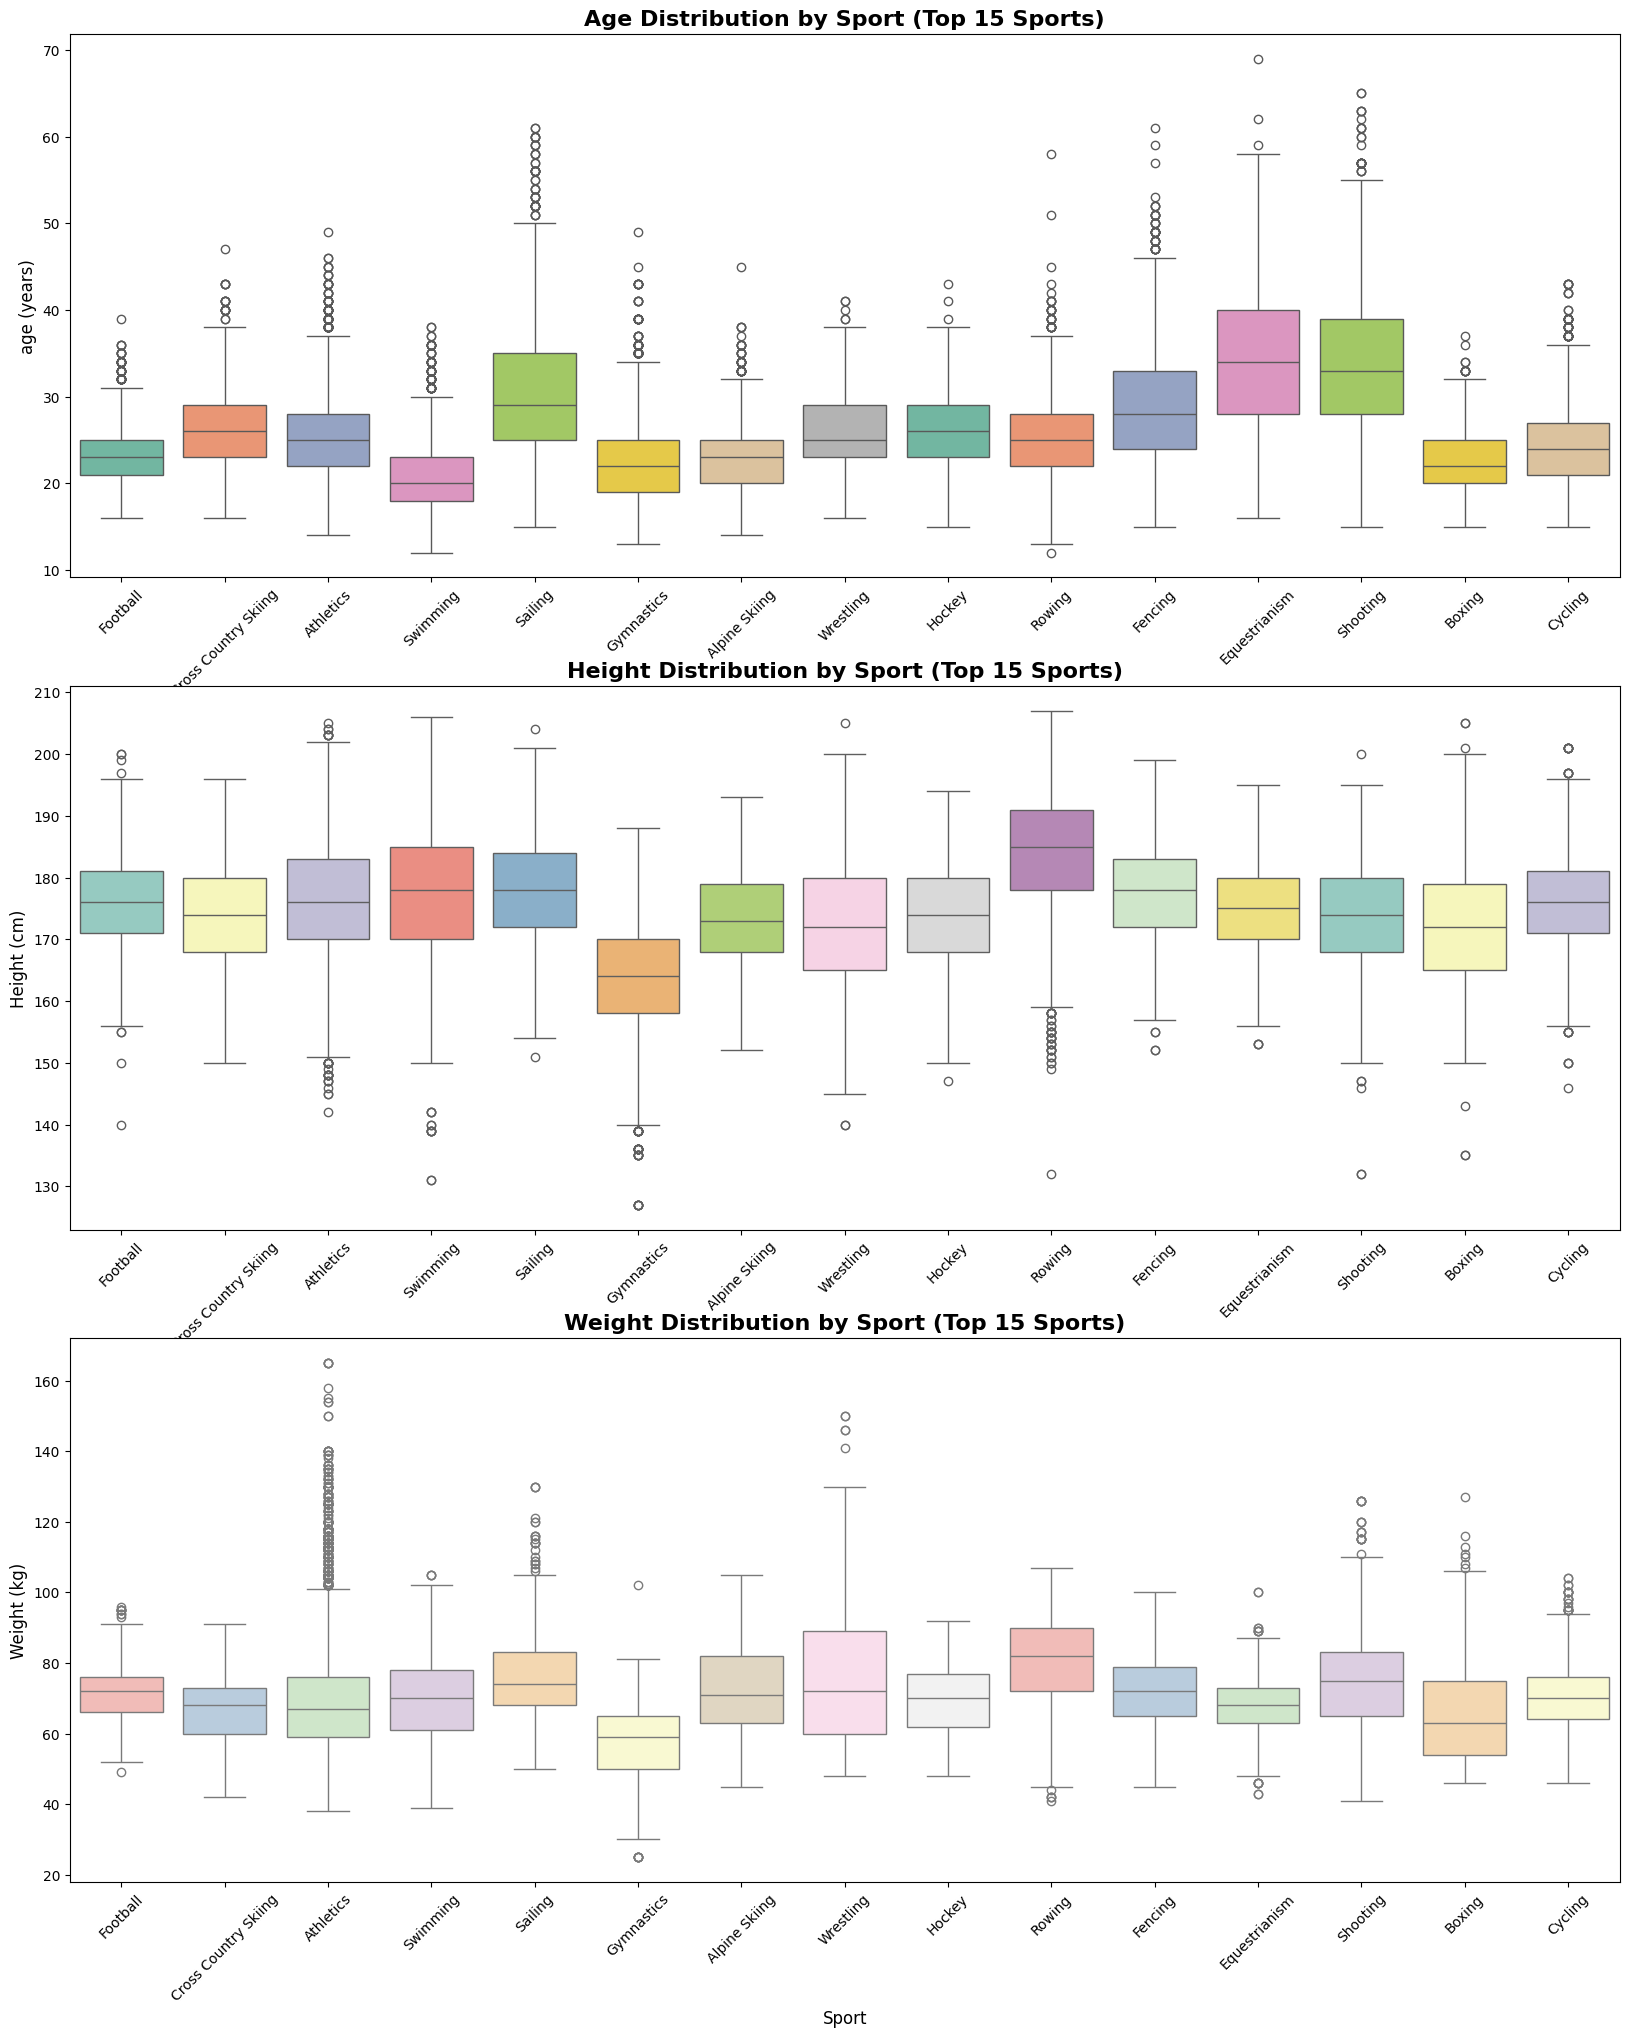

In [71]:
top_sports = df['sport'].value_counts().head(15).index
df_top_sports = df[df['sport'].isin(top_sports)]

fig, axes = plt.subplots(3, 1, figsize=(20, 24))

# Age by Sport
sns.boxplot(data=df_top_sports, x='sport', y='age', ax=axes[0], palette='Set2')
axes[0].set_title('Age Distribution by Sport (Top 15 Sports)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('sport', fontsize=12)
axes[0].set_ylabel('age (years)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Height by Sport
sns.boxplot(data=df_top_sports, x='sport', y='height', ax=axes[1], palette='Set3')
axes[1].set_title('Height Distribution by Sport (Top 15 Sports)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Sport', fontsize=12)
axes[1].set_ylabel('Height (cm)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Weight by Sport
sns.boxplot(data=df_top_sports, x='sport', y='weight', ax=axes[2], palette='Pastel1')
axes[2].set_title('Weight Distribution by Sport (Top 15 Sports)', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Sport', fontsize=12)
axes[2].set_ylabel('Weight (kg)', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

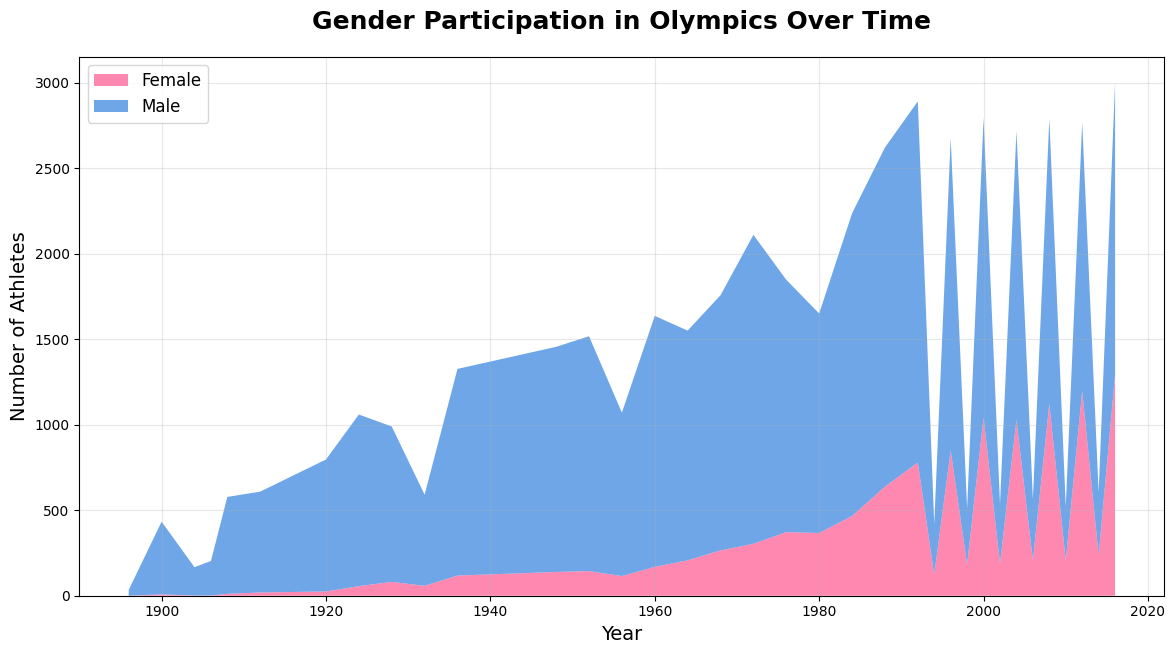

In [73]:
gender_time = df.groupby(['year', 'sex'])['id'].nunique().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7))
ax.stackplot(gender_time.index, 
             gender_time['F'], 
             gender_time['M'],
             labels=['Female', 'Male'],
             alpha=0.8,
             colors=['#FF6B9D', '#4A90E2'])

ax.set_title('Gender Participation in Olympics Over Time', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Number of Athletes', fontsize=14)
ax.legend(loc='upper left', fontsize=12)
ax.grid(True, alpha=0.3)

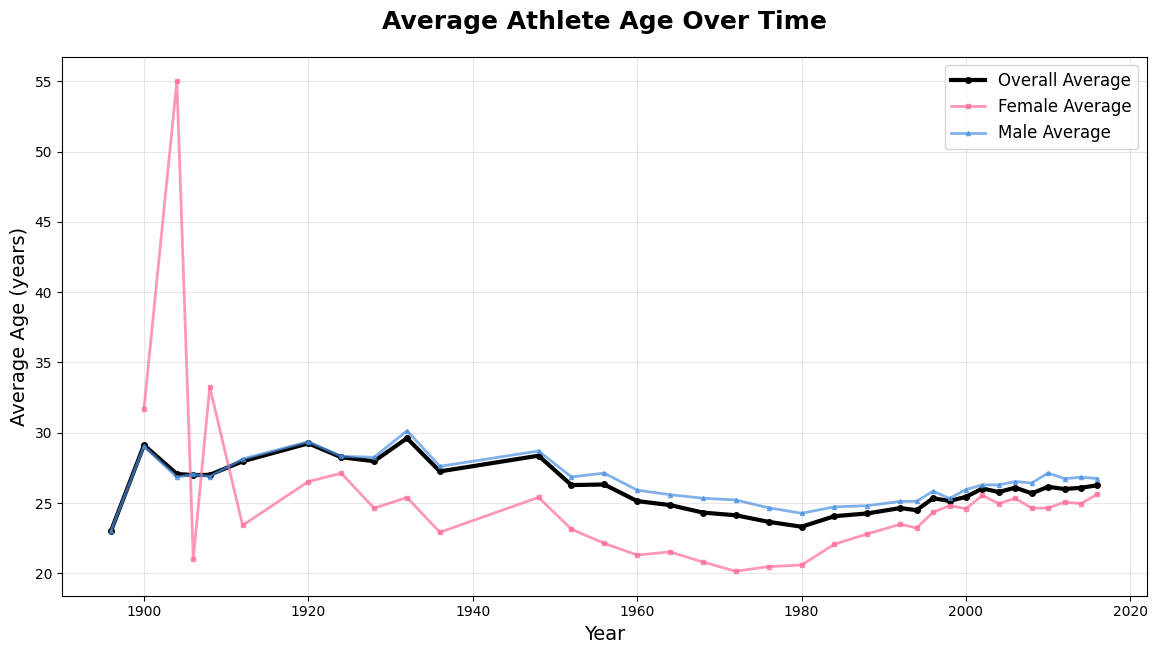

In [74]:
# Calculate average age by year, excluding NaN
avg_age_time = df.groupby('year')['age'].mean()

# Also split by gender for additional insight
avg_age_gender = df.groupby(['year', 'sex'])['age'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 7))

# Overall average
ax.plot(avg_age_time.index, avg_age_time.values, 
        linewidth=3, label='Overall Average', color='black', marker='o', markersize=4)

# By gender
ax.plot(avg_age_gender.index, avg_age_gender['F'], 
        linewidth=2, label='Female Average', color='#FF6B9D', marker='s', markersize=3, alpha=0.7)
ax.plot(avg_age_gender.index, avg_age_gender['M'], 
        linewidth=2, label='Male Average', color='#4A90E2', marker='^', markersize=3, alpha=0.7)

ax.set_title('Average Athlete Age Over Time', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Average Age (years)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

## The END